In [ ]:
import pandas as pd
from embeddings.bow import BoWEmbedder
from embeddings.word2vec import Word2VecEmbedder
#from embeddings.bert import BERTEmbedder
from reco_plots import MovieRecommender
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import nltk
nltk.download('all')


In [ ]:
# --- Config ---
POSTERS_BASE_PATH = Path.cwd().parent.parent / 'sorted_movie_posters_paligema'
CSV_PATH = "data/movie_plots.csv"
QUERY = "A hero fights to save the world from an evil villain using supernatural powers"
TOP_K = 5

# --- Chargement ---
df = pd.read_csv(CSV_PATH)
print(f"Dataset chargé : {len(df)} films\n")


def display_recommendations(results: pd.DataFrame, method_name: str):
    """Affiche les résultats avec les posters sous forme de grille matplotlib."""
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 6))
    fig.suptitle(f"Recommandations — {method_name}", fontsize=14, fontweight='bold')

    if len(results) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, results.iterrows()):
        img_path = POSTERS_BASE_PATH / row['movie_poster_path'].lstrip('/')

        if img_path.exists():
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'Image\nnon trouvée',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')

        ax.axis('off')
        score = f"{row['similarity_score']:.3f}"
        category = row.get('movie_category', '')
        # Titre court pour l'affichage
        plot_preview = row['movie_plot'][:60] + '...' if len(row['movie_plot']) > 60 else row['movie_plot']
        ax.set_title(f"{category}\nscore: {score}", fontsize=9)
        ax.set_xlabel(plot_preview, fontsize=7, wrap=True)

    plt.tight_layout()
    plt.show()
  


Dataset chargé : 5385 films



MÉTHODE : TF-IDF / Bag of Words
Index construit : (5385, 10000)
 movie_category  similarity_score
      animation          0.195406
    documentary          0.169746
         comedy          0.150782
         horror          0.139299
science Fiction          0.137204


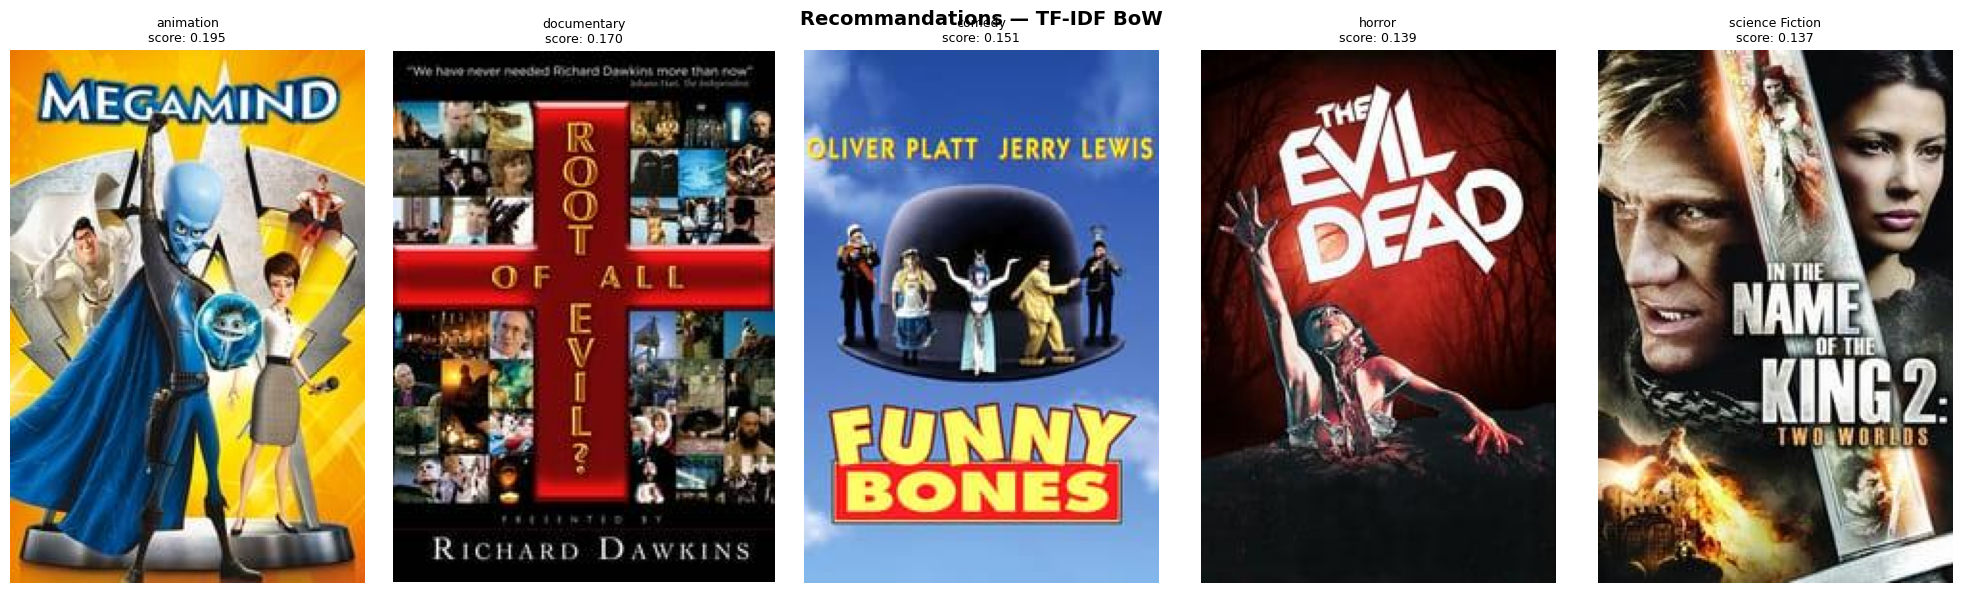

Figure sauvegardée : results_tf-idf_bow.png


In [16]:

# =========================================================
# TEST 1 : BoW
# =========================================================
print("=" * 50)
print("MÉTHODE : TF-IDF / Bag of Words")
print("=" * 50)
bow = BoWEmbedder()
rec_bow = MovieRecommender(bow, df)
rec_bow.build_index()
results_bow = rec_bow.recommend(QUERY, TOP_K)
print(results_bow[['movie_category', 'similarity_score']].to_string(index=False))
display_recommendations(results_bow, "TF-IDF BoW")


In [19]:

# =========================================================
# TEST 2 : Word2Vec
# =========================================================
print("\n" + "=" * 50)
print("MÉTHODE : Word2Vec")
print("=" * 50)
w2v = Word2VecEmbedder()
rec_w2v = MovieRecommender(w2v, df)
rec_w2v.build_index()
results_w2v = rec_w2v.recommend(QUERY, TOP_K)
print(results_w2v[['movie_category', 'similarity_score']].to_string(index=False))
display_recommendations(results_w2v, "Word2Vec")



MÉTHODE : Word2Vec


LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\Admin/nltk_data'
    - 'c:\\Users\\Admin\\anaconda3\\envs\\torch\\nltk_data'
    - 'c:\\Users\\Admin\\anaconda3\\envs\\torch\\share\\nltk_data'
    - 'c:\\Users\\Admin\\anaconda3\\envs\\torch\\lib\\nltk_data'
    - 'C:\\Users\\Admin\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:

# =========================================================
# TEST 3 : BERT
# =========================================================
print("\n" + "=" * 50)
print("MÉTHODE : BERT")
print("=" * 50)
bert = BERTEmbedder()
rec_bert = MovieRecommender(bert, df)
rec_bert.build_index()
results_bert = rec_bert.recommend(QUERY, TOP_K)
print(results_bert[['movie_category', 'similarity_score']].to_string(index=False))
display_recommendations(results_bert, "BERT")